In [ ]:
!pip install fomo-edge-ai==0.0.12

You must restart the session after running the above

In [1]:

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
  GPU: Tesla T4


In [10]:
!wget https://cdn.openwear.ai/dog-no-augmentation.v1i.yolov8.zip

--2026-06-15 18:00:12--  https://cdn.openwear.ai/dog-no-augmentation.v1i.yolov8.zip
Resolving cdn.openwear.ai (cdn.openwear.ai)... 104.21.44.33, 172.67.194.161, 2606:4700:3034::6815:2c21, ...
Connecting to cdn.openwear.ai (cdn.openwear.ai)|104.21.44.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 103694292 (99M) [application/x-zip-compressed]
Saving to: ‘dog-no-augmentation.v1i.yolov8.zip’

dog-no-augmentation 100%[===================>]  98.89M  29.8MB/s    in 3.7s    

2026-06-15 18:00:16 (26.4 MB/s) - ‘dog-no-augmentation.v1i.yolov8.zip’ saved [103694292/103694292]



In [ ]:
!rm -rf dog-no-augmentation.v1i.yolov8
!unzip -o dog-no-augmentation.v1i.yolov8.zip -d /content/dog-no-augmentation.v1i.yolov8

In `data.yaml` replace paths with

```
train: ./train/images
val: ./valid/images
test: ./test/images
```

In [4]:
import shutil
import zipfile
from pathlib import Path
import yaml
from huggingface_hub import hf_hub_download

DATASET_ROOT = Path("/content/dog-no-augmentation.v1i.yolov8")
data_yaml_path = DATASET_ROOT / "data.yaml"

# Quick sanity check — count images and labels
def count_split(split_dir):
    imgs = list(split_dir.rglob("*.jpg")) + list(split_dir.rglob("*.png")) + list(split_dir.rglob("*.jpeg"))
    lbl_dir = split_dir.parent / "labels"
    lbls = list(lbl_dir.rglob("*.txt")) if lbl_dir.exists() else []
    return len(imgs), len(lbls)

train_imgs, train_lbls = count_split(DATASET_ROOT / "train" / "images")
val_imgs, val_lbls     = count_split(DATASET_ROOT / "valid" / "images")
test_imgs, test_lbls   = count_split(DATASET_ROOT / "test" / "images")
print(f"Combined Train : {train_imgs} images, {train_lbls} label files")
print(f"Combined Val   : {val_imgs} images, {val_lbls} label files")
print(f"Combined Test  : {test_imgs} images, {test_lbls} label files")


Combined Train : 242 images, 242 label files
Combined Val   : 69 images, 69 label files
Combined Test  : 34 images, 34 label files


## 3 — Train FOMO-m

FOMO-m uses a **MobileNetV2 backbone (α=0.5)** with a single-pixel detection head.
Input resolution is **192** → output grid **24x24** (8× downsample).

Training uses:
- Adam, lr=3e-4, ReduceLROnPlateau on val F1
- Weighted CrossEntropy (background=1×, foreground=100×)
- No augmentation (plain resize + ImageNet normalisation)
- Val sweep over confidence thresholds every epoch

In [5]:
from fomo import FOMO

EPOCHS     = 100
BATCH      = 16
MODEL_SIZE = "m"            # "s" | "m" | "l"
PROJECT    = "runs/fomo"
RUN_NAME   = f"garlic_{MODEL_SIZE}"

model = FOMO(model_path=None, size=MODEL_SIZE, nb_classes=1, device=device)
print(f"Model: FOMO-{MODEL_SIZE}")
print(f"  Input size : {model.input_size}×{model.input_size}")
print(f"  Grid size  : {model.input_size//8}×{model.input_size//8}")
print(f"  Classes    : {model.nb_classes}")

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)

results = model.train(
    allow_experimental=True,
    data=str(data_yaml_path),
    epochs=EPOCHS,
    batch=BATCH,
    lr0=3e-4,
    eval_interval=1,
    workers=2,
    device=device,
    project=PROJECT,
    name=RUN_NAME,
    exist_ok=True,

    # Early stopping
    patience=12,

    # Regularization & Speedups
    optimizer="adamw",
    weight_decay=1e-4,
    ema=True,
    amp=True,

    # Data Augmentations
    mosaic_prob=0.0,
    flip_prob=0.5,
    hsv_prob=0.0,
)

save_dir = Path(results["save_dir"])
print(f"\nTraining complete. Saved to: {save_dir}")


18:16:29  Using device: cuda
18:16:29  Setting up training...
18:16:29  FOMOLoss: nc=1, fg_weight=100.0
18:16:29  FOMOLoss rebuilt with resolved dataset nc=1
18:16:29  FOMO Training: Data augmentation enabled.
18:16:29    mosaic_prob: 0.0
18:16:29    mixup_prob: 0.0
18:16:29    flip_prob: 0.5
18:16:29    hsv_prob: 0.0
18:16:29  Loading 242 YOLO annotations from train/labels...
18:16:29  Loaded 242 YOLO annotations from train/labels in 0.13s
18:16:29  FOMO training dataset: 242 images
18:16:29  Grid size: 24×24 (imgsz=192, downsample=8)
18:16:29  Iterations per epoch: 16 (batch_per_rank=16, world_size=1)
18:16:29  Optimizer: adamw
18:16:29    - pg0 (BN): 19 params
18:16:29    - pg1 (Conv, wd=0.0001): 20 params
18:16:29    - pg2 (Bias): 20 params
18:16:29  Using mixed precision training (AMP)
18:16:29  Using EMA with decay=0.9998, tau=2000
18:16:29  Saving to: runs/fomo/garlic_m
18:16:29  Starting training for 100 epochs
18:16:29  Model: FOMO-m
18:16:29  Batch size: 16
18:16:29  Learning

Model: FOMO-m
  Input size : 192×192
  Grid size  : 24×24
  Classes    : 1


18:16:37  Epoch 1 - Average loss: 0.6414
18:16:37  Running FOMO validation for epoch 1
18:16:42  Epoch 1 val | loss=0.6967 | F1=0.3316 | P=0.2002 | R=0.9636 | MeanDist=0.864 | thresh=0.25 | nms_r=1 | TP=1641 FP=6554 FN=62 | LR=0.000300
18:16:42  New best model saved - Epoch 1: metrics/F1=0.3316
18:16:42  Checkpoint saved: runs/fomo/garlic_m/weights/last.pt
18:16:45  Epoch 2 - Average loss: 0.3768
18:16:45  Running FOMO validation for epoch 2
18:16:50  Epoch 2 val | loss=0.7130 | F1=0.3617 | P=0.2670 | R=0.5608 | MeanDist=0.811 | thresh=0.50 | nms_r=1 | TP=955 FP=2622 FN=748 | LR=0.000300
18:16:50  New best model saved - Epoch 2: metrics/F1=0.3617
18:16:50  Checkpoint saved: runs/fomo/garlic_m/weights/last.pt
18:16:53  Epoch 3 - Average loss: 0.3092
18:16:53  Running FOMO validation for epoch 3
18:16:59  Epoch 3 val | loss=0.4692 | F1=0.4720 | P=0.3212 | R=0.8896 | MeanDist=0.679 | thresh=0.65 | nms_r=1 | TP=1515 FP=3201 FN=188 | LR=0.000299
18:16:59  New best model saved - Epoch 3: met


----------------------------------------------------------------
FOMO weights are hosted externally at huggingface.co/fomo-edge-ai/FOMO
under cc-by-nc-4.0.
They are treated as externally hosted, ImageNet-derived weights and
are not redistributed by FOMO. By downloading them you accept
the Hugging Face repository license terms.
----------------------------------------------------------------


Training complete. Saved to: runs/fomo/garlic_m


In [6]:

from fomo import FOMO

weights_dir = save_dir / "weights"
best_pt  = weights_dir / "best.pt"
last_pt  = weights_dir / "last.pt"
ckpt_path = best_pt if best_pt.exists() else last_pt

trained = FOMO(str(ckpt_path), device=device)
print(f"Loaded: {ckpt_path.name}")
print(f"  family : {trained.family}")
print(f"  size   : {trained.size}")
print(f"  imgsz  : {trained.input_size}")
print(f"  nc     : {trained.nb_classes}")


Loaded: best.pt
  family : fomo
  size   : m
  imgsz  : 192
  nc     : 1


## 4 — Visualize Model Predictions and Heatmaps

Below, we define a helper function to run the trained model on sample validation images, extract the raw activation values (logits), convert them to probability heatmaps, and overlay them alongside the point predictions.

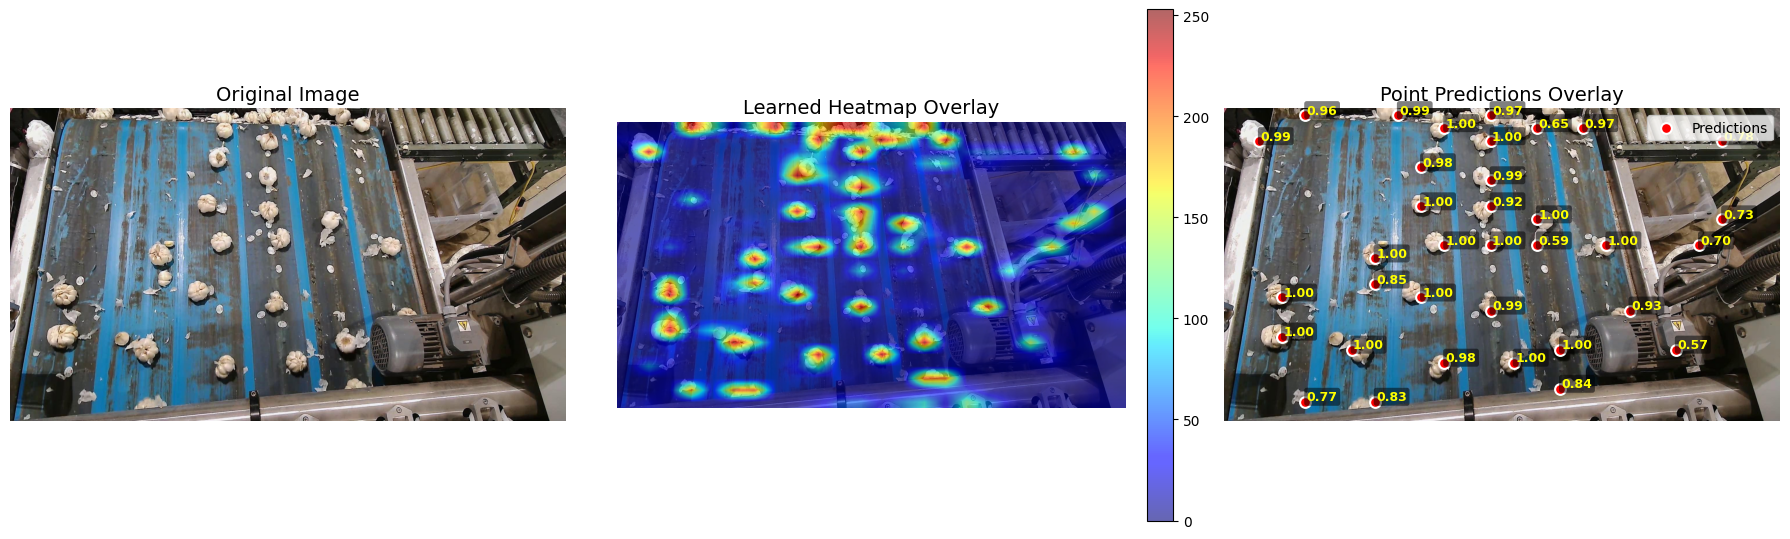

In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def visualize_fomo_predictions(model, image_path, conf_threshold=0.25):
    # 1. Load original image
    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    # 2. Get point predictions using model.predict
    results = model.predict(image_path, conf=conf_threshold)

    # 3. Get raw logits/heatmaps by running preprocess + forward pass
    input_tensor, _, _, _ = model._preprocess(image_path)
    with torch.no_grad():
        logits = model._forward(input_tensor.to(model.device))

    # 4. Compute probabilities (heatmap)
    # logits shape: (1, C + 1, H_grid, W_grid) where C + 1 is background + classes
    probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Col 1: Original Image
    axes[0].imshow(img)
    axes[0].set_title("Original Image", fontsize=14)
    axes[0].axis("off")

    # Col 2: Heatmap Overlay
    axes[1].imshow(img)
    # Take the maximum class probability heatmap across all foreground classes
    heatmap = probs[1:].max(axis=0)
    # Resize heatmap to original image dimensions for overlay
    heatmap_resized = Image.fromarray((heatmap * 255).astype(np.uint8)).resize((w, h), Image.Resampling.BILINEAR)
    im = axes[1].imshow(heatmap_resized, alpha=0.6, cmap="jet")
    axes[1].set_title("Learned Heatmap Overlay", fontsize=14)
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    # Col 3: Point Predictions Overlay
    axes[2].imshow(img)
    if results.points is not None and len(results.points) > 0:
        pts = results.points.xy.cpu().numpy() if isinstance(results.points.xy, torch.Tensor) else results.points.xy
        confs = results.points.conf.cpu().numpy() if isinstance(results.points.conf, torch.Tensor) else results.points.conf
        axes[2].scatter(pts[:, 0], pts[:, 1], color="red", marker="o", s=60, edgecolors="white", linewidths=1.5, label="Predictions")
        for pt, conf in zip(pts, confs):
            axes[2].annotate(f"{conf:.2f}", (pt[0] + 5, pt[1] - 5), color="yellow", fontsize=9, weight="bold",
                             bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5, ec="none"))
        axes[2].legend(loc="upper right")
    axes[2].set_title("Point Predictions Overlay", fontsize=14)
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# Run visualization on a sample image from the validation set
val_images = list((DATASET_ROOT / "valid" / "images").glob("*.jpg"))
if val_images:
    visualize_fomo_predictions(trained, val_images[0], conf_threshold=0.5)
else:
    print("No validation images found to visualize.")

Generating GIF from 15 images. This may take a moment...
Saved GIF to fomo_validation_results.gif


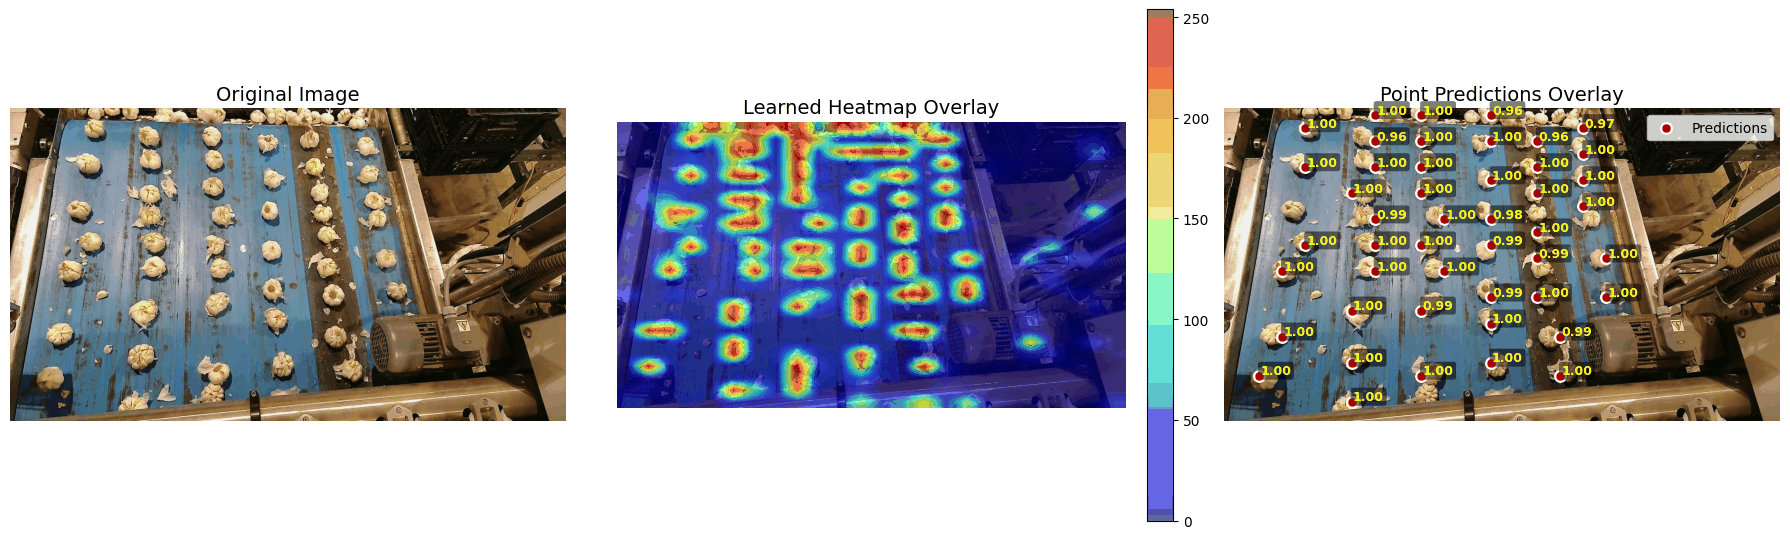

In [10]:
import io
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from IPython.display import Image as IPythonImage, display

def get_fomo_visualization_frame(model, image_path, conf_threshold=0.25):
    """Generates a single visualization frame and returns it as a PIL Image."""
    # 1. Load original image
    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    # 2. Get point predictions using model.predict
    results = model.predict(image_path, conf=conf_threshold)

    # 3. Get raw logits/heatmaps by running preprocess + forward pass
    input_tensor, _, _, _ = model._preprocess(image_path)
    with torch.no_grad():
        logits = model._forward(input_tensor.to(model.device))

    # 4. Compute probabilities (heatmap)
    probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Col 1: Original Image
    axes[0].imshow(img)
    axes[0].set_title("Original Image", fontsize=14)
    axes[0].axis("off")

    # Col 2: Heatmap Overlay
    axes[1].imshow(img)
    heatmap = probs[1:].max(axis=0)
    heatmap_resized = Image.fromarray((heatmap * 255).astype(np.uint8)).resize((w, h), Image.Resampling.BILINEAR)
    im = axes[1].imshow(heatmap_resized, alpha=0.6, cmap="jet")
    axes[1].set_title("Learned Heatmap Overlay", fontsize=14)
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    # Col 3: Point Predictions Overlay
    axes[2].imshow(img)
    if results.points is not None and len(results.points) > 0:
        pts = results.points.xy.cpu().numpy() if isinstance(results.points.xy, torch.Tensor) else results.points.xy
        confs = results.points.conf.cpu().numpy() if isinstance(results.points.conf, torch.Tensor) else results.points.conf
        axes[2].scatter(pts[:, 0], pts[:, 1], color="red", marker="o", s=60, edgecolors="white", linewidths=1.5, label="Predictions")
        for pt, conf in zip(pts, confs):
            axes[2].annotate(f"{conf:.2f}", (pt[0] + 5, pt[1] - 5), color="yellow", fontsize=9, weight="bold",
                             bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5, ec="none"))
        axes[2].legend(loc="upper right")
    axes[2].set_title("Point Predictions Overlay", fontsize=14)
    axes[2].axis("off")

    plt.tight_layout()

    # --- NEW: Save plot to a buffer instead of showing it ---
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)

    # Convert buffer to a PIL Image
    frame = Image.open(buf).convert("RGB")

    # CRITICAL: Close the figure to prevent memory leaks in the loop
    plt.close(fig)

    return frame

# --- GIF Generation Logic ---

# 1. Grab and sort the validation images
val_images = sorted(list((DATASET_ROOT / "valid" / "images").glob("*.jpg")))

# Limit to a smaller subset so the GIF doesn't take forever to generate (e.g., first 15 images)
num_images_for_gif = min(15, len(val_images))

if num_images_for_gif > 0:
    print(f"Generating GIF from {num_images_for_gif} images. This may take a moment...")
    frames = []

    # 2. Iterate and create frames
    for img_path in val_images[:num_images_for_gif]:
        frame = get_fomo_visualization_frame(trained, img_path, conf_threshold=0.9)
        frames.append(frame)

    # 3. Save as GIF
    output_gif_path = "fomo_validation_results.gif"
    frames[0].save(
        output_gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=800, # Display each frame for 800 milliseconds
        loop=0        # Loop forever
    )
    print(f"Saved GIF to {output_gif_path}")

    # 4. Render the GIF directly in the Colab cell output
    with open(output_gif_path, "rb") as f:
        display(IPythonImage(data=f.read(), format='png'))
else:
    print("No validation images found to visualize.")

Evaluating counting accuracy on 69 validation images...

--- Counting Evaluation Metrics ---
Mean True Count                 : 24.72
Mean Predicted Count            : 40.28
Mean Absolute Error (MAE)       : 16.159 (average count difference per image)
Root Mean Squared Error (RMSE)  : 16.553
Overall Counting Accuracy       : 34.64%


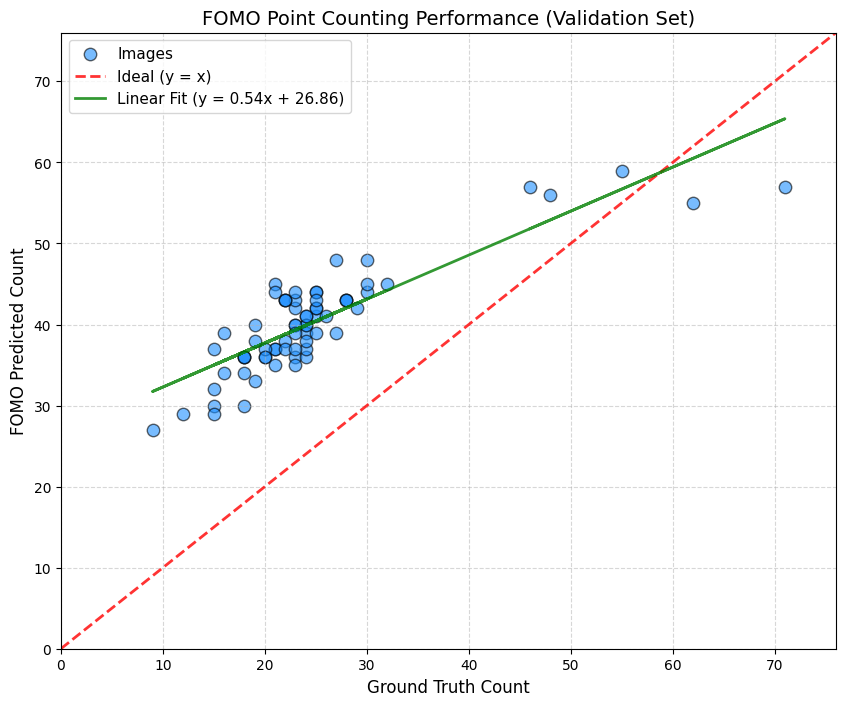

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from fomo.data import load_data_config

def evaluate_counting_accuracy(model, dataset_yaml, conf_threshold=0.25, nms_radius=1):
    cfg = load_data_config(dataset_yaml)
    val_images = cfg.get("val_img_files", [])
    val_labels = cfg.get("val_label_files", [])

    if not val_images:
        print("No validation images found in dataset config.")
        return

    true_counts = []
    pred_counts = []

    print(f"Evaluating counting accuracy on {len(val_images)} validation images...")

    for img_path, lbl_path in zip(val_images, val_labels):
        # Count ground truth points from label file
        true_count = 0
        if Path(lbl_path).exists():
            with open(lbl_path, 'r') as f:
                true_count = len([line for line in f.read().strip().split('\n') if line.strip()])
        true_counts.append(true_count)

        # Run inference
        results = model.predict(img_path, conf=conf_threshold, nms_radius=nms_radius)
        pred_count = len(results.points) if results.points is not None else 0
        pred_counts.append(pred_count)

    true_counts = np.array(true_counts)
    pred_counts = np.array(pred_counts)

    # Calculate counting metrics
    errors = pred_counts - true_counts
    abs_errors = np.abs(errors)

    mae = np.mean(abs_errors)
    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)

    mean_true = np.mean(true_counts)
    mean_pred = np.mean(pred_counts)

    # Overall count accuracy
    accuracy = 1.0 - (mae / mean_true) if mean_true > 0 else 1.0

    print("\n--- Counting Evaluation Metrics ---")
    print(f"Mean True Count                 : {mean_true:.2f}")
    print(f"Mean Predicted Count            : {mean_pred:.2f}")
    print(f"Mean Absolute Error (MAE)       : {mae:.3f} (average count difference per image)")
    print(f"Root Mean Squared Error (RMSE)  : {rmse:.3f}")
    print(f"Overall Counting Accuracy       : {accuracy * 100:.2f}%")

    # Scatter plot comparing True vs Predicted Counts
    plt.figure(figsize=(10, 8))
    max_count = max(true_counts.max(), pred_counts.max()) + 5

    plt.scatter(true_counts, pred_counts, alpha=0.6, color='dodgerblue', edgecolors='k', s=80, label='Images')
    plt.plot([0, max_count], [0, max_count], 'r--', alpha=0.8, linewidth=2, label='Ideal (y = x)')

    if len(true_counts) > 1:
        m, b = np.polyfit(true_counts, pred_counts, 1)
        plt.plot(true_counts, m * true_counts + b, color='green', alpha=0.8, linewidth=2,
                 label=f'Linear Fit (y = {m:.2f}x + {b:.2f})')

    plt.xlim(0, max_count)
    plt.ylim(0, max_count)
    plt.xlabel('Ground Truth Count', fontsize=12)
    plt.ylabel('FOMO Predicted Count', fontsize=12)
    plt.title('FOMO Point Counting Performance (Validation Set)', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11)
    plt.show()

# Run counting evaluation
evaluate_counting_accuracy(trained, str(data_yaml_path), conf_threshold=0.25)